In [1]:
# Test script 1

In [1]:
# Test MC for BMR

In [22]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# === Path config ===
BMR_DIR = "/glade/work/awells/air_quality/BMR/"

In [6]:
# === Load data ===
bmr_file = "GBD_BMR_Country_COPD_newlabels_1990-2009.nc"
bmr_path = os.path.join(BMR_DIR, bmr_file)
BMR = xr.open_dataarray(bmr_path)  # three quantiles

In [10]:
BMR_mean = BMR.sel(quantile="mean")
BMR_lower = BMR.sel(quantile="lower")
BMR_upper = BMR.sel(quantile="upper")

In [11]:
# Standard deviation for BMR
bmr_std = (BMR_upper - BMR_lower) / (2 * 1.96)

In [20]:
# Sample BMR: shape = (samples, country)
bmr_samples = np.random.normal(
    loc=BMR_mean.data,
    scale=bmr_std.data,
    size=(1000, len(BMR.country))
)

# Wrap in xarray for nice labeling:
bmr_samples = xr.DataArray(
    bmr_samples,
    dims=("sample", "country"),
    coords={"sample": np.arange(1000), "country": BMR_mean.country}
)

26.8508097965778
16.858632698522218
8.193702372766339
26.01843310266805
34.04675827405267
10.910596907699302
5.452582834059867
32.82903656604693
33.048809770011744
32.81592978862621


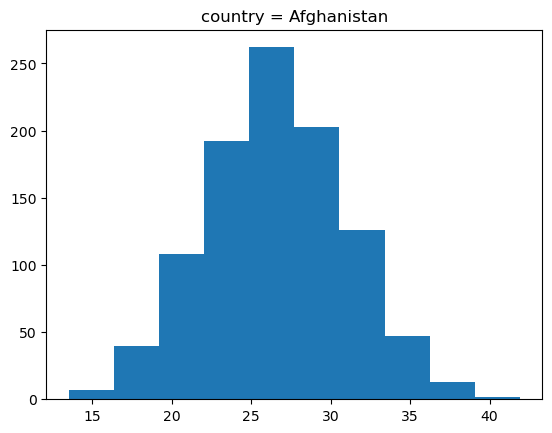

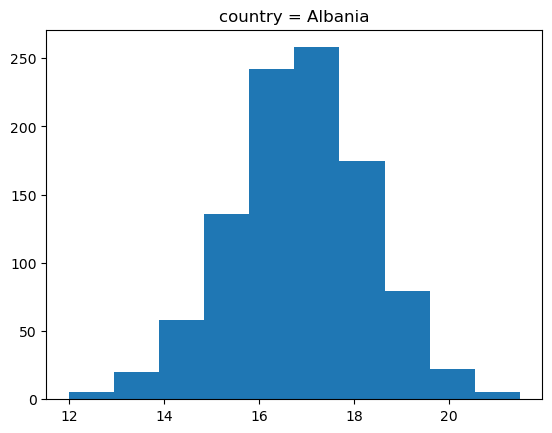

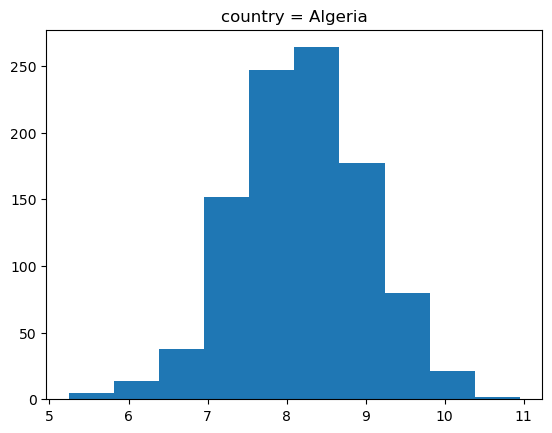

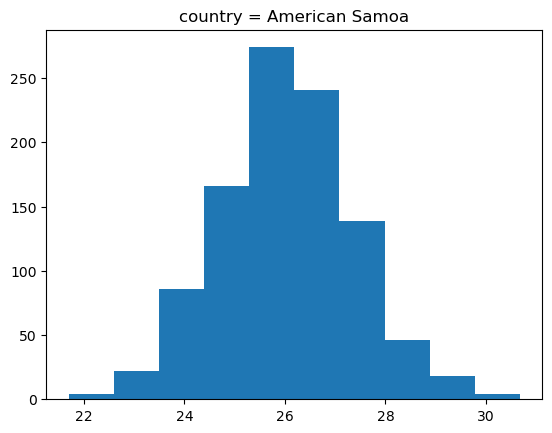

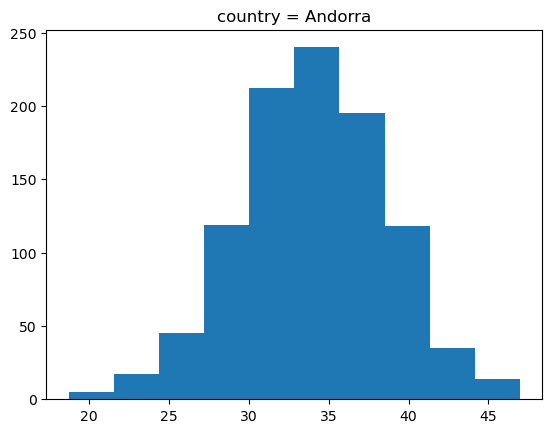

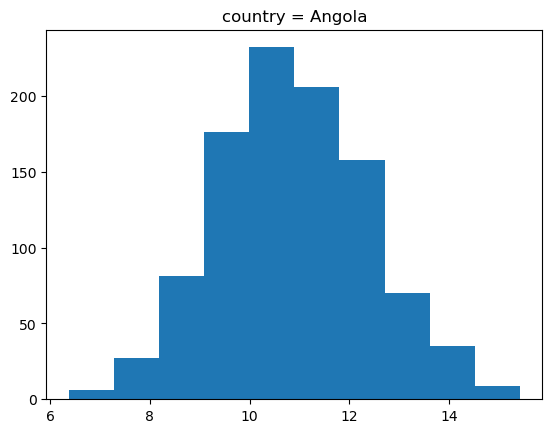

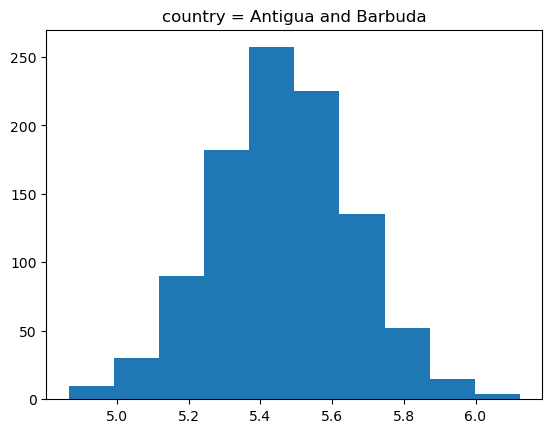

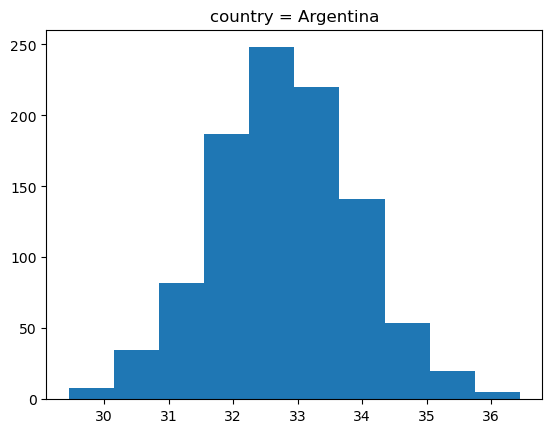

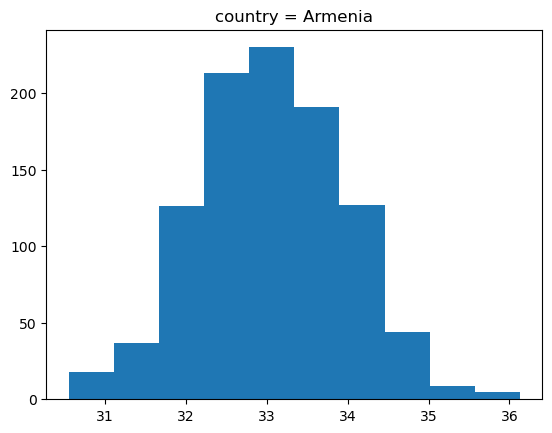

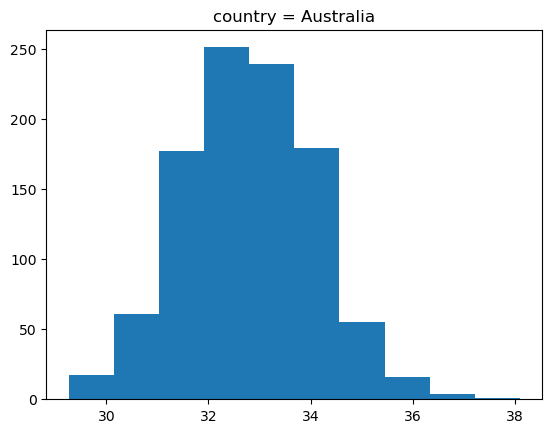

In [28]:
for i in range(10):
    plt.figure(i)
    print(BMR_mean.isel(country=i).values)
    bmr_samples.isel(country=i).plot.hist()